# March Madness LSTM Recurrent Model

This notebook builds an LSTM-based recurrent neural network to predict game outcomes using:
1. **Team Encoder**: LSTM to encode each team's historical stats to a latent vector
2. **Prediction Head**: Binary classifier combining two team embeddings
3. **Walk-Forward Training**: Temporal validation preventing future leakage

## Setup and Configuration

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from tqdm import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set seeds for reproducibility
import os, random
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Libraries imported")
print(f"  Device: {device}")

✓ Libraries imported
  Device: cuda


## Hyperparameters

In [12]:
# Model hyperparameters (easily adjustable)
CONFIG = {
    # Model architecture
    'latent_dim': 32,              # Dimensionality of team latent vector
    'hidden_dim': 64,             # LSTM hidden dimension
    'num_layers': 3,               # Number of LSTM layers
    'dropout': 0.3,                # Dropout rate
    
    # Training
    'batch_size': 32,
    'learning_rate': 1e-3,
    'epochs': 5,
    'max_prev_games': 20,          # Max number of previous games to consider
}


## 1. Load and Prepare Data

In [13]:
# Load processed data
df = pd.read_csv("./InputData.csv")
df = df.sort_values(by='Date').reset_index(drop=True)

# drop nan 

# Standardize statistics
stat1 = sorted([c for c in df.columns if c.startswith('1-')])
stat2 = [c.replace('1-','2-') for c in stat1]

train_mask = (df['is_tournament_game'] == False)
mu = df.loc[train_mask, stat1].mean()
sd = df.loc[train_mask, stat1].std().replace(0, 1)

df.loc[:, stat1] = (df[stat1] - mu) / sd
df.loc[:, stat2] = (df[stat2] - mu.values) / sd.values

df.columns

Index(['Game ID', 'Team 1', 'Team 2', 'Date', 'Site', 'Outcome', 'is_tournament_game', '1-ORtg', '1-DRtg', '1-3PAr', '1-TS%', '1-TRB%', '1-AST%', '1-STL%', '1-BLK%', '1-eFG%', '1-TOV%', '1-ORB%', '1-FTr', '1-oeFG%', '1-oTOV%', '1-oDRB%', '1-oFTr', '1-Pace', '1-o3PAr', '2-ORtg', '2-DRtg', '2-3PAr', '2-TS%', '2-TRB%', '2-AST%', '2-STL%', '2-BLK%', '2-eFG%', '2-TOV%', '2-ORB%', '2-FTr', '2-oeFG%', '2-oTOV%', '2-oDRB%', '2-oFTr', '2-Pace', '2-o3PAr'], dtype='object')

In [14]:
def compute_elo(df, k=20, base_elo=1000):
    # copy to avoid modifying original
    df = df.copy()
    
    # track elo per team
    team_elo = defaultdict(lambda: base_elo)
    
    # columns to store *pre-game* elo (the correct ones)
    pre1 = []
    pre2 = []
    
    for i, row in df.iterrows():
        t1 = row['Team 1']
        t2 = row['Team 2']
        outcome = row['Outcome']         # 1 if Team1 wins
        
        elo1 = team_elo[t1]
        elo2 = team_elo[t2]
        
        # Store PRE-GAME Elo (no leakage)
        pre1.append(elo1)
        pre2.append(elo2)
        
        # --- now update elo based on game result ---
        # expected score
        expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
        expected2 = 1 - expected1
        
        # actual score
        score1 = outcome
        score2 = 1 - outcome
        
        # update
        new_elo1 = elo1 + k * (score1 - expected1)
        new_elo2 = elo2 + k * (score2 - expected2)
        
        team_elo[t1] = new_elo1
        team_elo[t2] = new_elo2
    
    # Assign new columns
    df['Elo1'] = pre1
    df['Elo2'] = pre2
    
    return df
    
df = compute_elo(df, k=100, base_elo=1000)

In [15]:
def compute_glm_quality(df):
    import statsmodels.api as sm
    
    df_glm = df.copy()
    df_glm['PointDiff'] = df_glm['Score1'] - df_glm['Score2']
    
    team_ids = sorted(df['Team 1'].unique())
    mapping = {t:i for i,t in enumerate(team_ids)}

    X = np.zeros((len(df_glm), len(team_ids)))
    for idx, row in df_glm.iterrows():
        X[idx, mapping[row['Team 1']]] = 1
        X[idx, mapping[row['Team 2']]] = -1

    glm = sm.GLM(df_glm['PointDiff'], X, family=sm.families.Gaussian()).fit()
    quality = glm.params

    df['Q1'] = df['Team 1'].map(lambda t: quality[mapping[t]])
    df['Q2'] = df['Team 2'].map(lambda t: quality[mapping[t]])
    return df


## 2. Team Encoder LSTM Model

In [16]:
class TeamEncoder(nn.Module):
    """Encodes a team's game history to a latent vector using LSTM."""
    
    def __init__(self, input_size, hidden_dim, num_layers, latent_dim, dropout=0.1, max_prev_games=None):
        super(TeamEncoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.latent_dim = latent_dim
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        if max_prev_games is not None:
            self.pos_emb = nn.Embedding(max_prev_games, input_size)  # assume max 300 games
        self.input_norm = nn.LayerNorm(input_size)

        # Project LSTM output to latent space
        self.projection = nn.Linear(hidden_dim*2, latent_dim)

    def forward(self, x, lengths):

        B, L, F = x.shape
        device = x.device
        
        # ---- POSITIONAL EMBEDDING ----
        if hasattr(self, 'pos_emb'):
            pos_ids = torch.arange(L, device=device).unsqueeze(0).expand(B, L)
            pos_vectors = self.pos_emb(pos_ids)  # (B, L, F)

            # inject position
            x = x + pos_vectors

        x = self.input_norm(x)

        # Pack for LSTM
        clamped = lengths.clamp(min=1)
        packed = pack_padded_sequence(x, clamped.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, _) = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)   # (B, Lmax, H)

        # build mask: 1 for real steps, 0 for pad
        B, Lmax, H = out.shape
        device = out.device
        mask = torch.arange(Lmax, device=device).unsqueeze(0) < lengths.unsqueeze(1)  # (B,Lmax)
        mask = mask.float().unsqueeze(-1)  # (B,Lmax,1)

        # masked mean over time
        sum_out = (out * mask).sum(dim=1)                  # (B,H)
        len_f = lengths.clamp(min=1).float().unsqueeze(1)  # (B,1)
        mean_out = sum_out / len_f

        last_hidden = h_n[-1]  # (B,H)

        # combine last + mean then project
        combined = torch.cat([last_hidden, mean_out], dim=1)      # (B, 2H)
        self.projection = getattr(self, "projection", nn.Linear(2*self.hidden_dim, self.latent_dim)).to(device)
        latent = self.projection(combined)

        # zero out for zero-length sequences
        latent = latent.masked_fill((lengths == 0).unsqueeze(1).to(device), 0.0)
        return latent


class StaticEncoder(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, latent_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(latent_dim, latent_dim)
        )
    def forward(self, x):
        return self.net(x)


class PredictionHead(nn.Module):
    """Binary classifier head that combines two team embeddings."""
    
    def __init__(self, latent_dim, hidden_dim=64, dropout=0.1):
        super(PredictionHead, self).__init__()
        
        # Take difference between teams as input
        self.fc1 = nn.Linear(latent_dim * 3, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 1)

        self.pre_fc_norm = nn.LayerNorm(latent_dim * 3)
        self.post_fc_norm = nn.LayerNorm(hidden_dim)



    def forward(self, team_a_latent, team_b_latent):
        """
        Args:
            team_a_latent: (batch_size, latent_dim)
            team_b_latent: (batch_size, latent_dim)
        Returns:
            prob: (batch_size, 1) - probability team A wins
        """
        matchup = team_a_latent - team_b_latent
        concat = torch.cat([team_a_latent, team_b_latent, matchup], dim=1)
        concat = self.pre_fc_norm(concat)
        x = self.relu(self.fc1(concat))
        x = self.post_fc_norm(x)
        x = self.dropout(x)
        logits = self.fc2(x)             # (batch,1)
        
        return logits


class RecurrentGamePredictor(nn.Module):
    """Complete model: team encoders + prediction head."""
    
    def __init__(self, input_size, hidden_dim, num_layers, latent_dim, dropout=0.3, max_prev_games=None):
        super(RecurrentGamePredictor, self).__init__()
        
        # Shared team encoder
        self.encoder = TeamEncoder(
            input_size=input_size,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            latent_dim=latent_dim,
            dropout=dropout,
            max_prev_games=max_prev_games
        )

        self.encoder_static = StaticEncoder(in_dim=1, latent_dim=latent_dim)

        # Prediction head
        self.head = PredictionHead(latent_dim, hidden_dim=hidden_dim, dropout=dropout)
        
    def forward(self, team_a_seq, len_a, team_b_seq, len_b, team_a_static, team_b_static):
        """
        Args:
            team_a_seq: (batch_size, seq_length, input_size)
            team_b_seq: (batch_size, seq_length, input_size)
            team_a_static: (batch_size, 2)
            team_b_static: (batch_size, 2)
        Returns:
            prob: (batch_size, 1) - probability team A wins
        """
        a_seq = self.encoder(team_a_seq, len_a)
        b_seq = self.encoder(team_b_seq, len_b)

        a_static = self.encoder_static(team_a_static)
        b_static = self.encoder_static(team_b_static)

        a_total = a_seq + a_static
        b_total = b_seq + b_static

        logits = self.head(a_total, b_total)
        return logits

print("✓ Model architecture defined")
print(f"  TeamEncoder: LSTM({CONFIG['hidden_dim']}) -> Linear({CONFIG['latent_dim']})")
print(f"  PredictionHead: Concat(2×{CONFIG['latent_dim']}) -> Binary")

✓ Model architecture defined
  TeamEncoder: LSTM(64) -> Linear(32)
  PredictionHead: Concat(2×32) -> Binary


In [17]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.75):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        prob = torch.sigmoid(logits)
        pt = targets * prob + (1 - targets) * (1 - prob)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()


## 3. Data Preparation for Walk-Forward Training

In [18]:
class GameSequenceDataset(torch.utils.data.Dataset):

    """
    PyTorch Dataset for NCAA basketball games with pre-built sequential arrays.
    
    For each game, returns:
    - team_1_seq: (n_prev_games1, n_features) - Team 1's previous games
    - team_2_seq: (n_prev_games2, n_features) - Team 2's previous games  
    - outcome: 0 or 1 (Team 1 win?)
    
    Uses pre-built arrays and slicing for fast access.
    """
    
    def __init__(self, df, use_indices=None):
        """
        Args:
            df: DataFrame with columns: Team 1, Team 2, Date, Site, Outcome, 
                1-ORtg, 1-DRtg, ... (stats prefixed with 1- and 2-)
        """
        self.df = df.reset_index(drop=True)
        self.df = compute_elo(self.df, k=100, base_elo=1000)
        # Auto-detect stat columns
        self.stat_cols = sorted([col for col in df.columns if col.startswith('1-')])
        self.stat_cols_team2 = [col.replace('1-', '2-') for col in self.stat_cols]
        self.team_games = defaultdict(list)

        # Feature engineering
        self._prepare_features()
        
        # Build sequential arrays from ALL games
        self._build_sequential_arrays()
        
        # Set which indices this dataset will expose
        if use_indices is not None:
            self.active_indices = use_indices
        else:
            self.active_indices = list(range(len(self.df)))


    def __len__(self):
        return len(self.active_indices)

    def n_features(self):
        return len(self.stat_cols)

    def _prepare_features(self):
        """Encode categorical variables and sort chronologically."""
        # 1. Encode Team names
        unique_teams = pd.concat([self.df['Team 1'], self.df['Team 2']]).unique()
        self.team_encoder = {team: idx for idx, team in enumerate(sorted(unique_teams))}
        self.n_teams = len(self.team_encoder)
        self.df['Team 1'] = self.df['Team 1'].map(self.team_encoder)
        self.df['Team 2'] = self.df['Team 2'].map(self.team_encoder)
        
        # # 2. Encode Site
        # site_map = {'home': 1.0, 'away': 0.0, 'neutral': 0.5}
        # self.df['1-Site'] = self.df['Site'].map(site_map).fillna(0.5)

        # # For Team 2, reverse the mapping (home<->away)
        # inv_site_map = {'home': 0.0, 'away': 1.0, 'neutral': 0.5}
        # self.df['2-Site'] = self.df['Site'].map(inv_site_map).fillna(0.5)
        
        # self.stat_cols.append('1-Site')
        # self.stat_cols_team2.append('2-Site')
        
        # 3. Sort by date
        # self.df['Date'] = pd.to_datetime(self.df['Date'])
    
    def _build_sequential_arrays(self):
        """
        Pre-build arrays for each team containing their game stats in order.
        
        Creates:
        - self.team_arrays: dict[team_id -> (n_games, n_features) array]
        - self.team_game_map: dict[team_id -> list of (global_idx, local_idx)]
        """
        
        # First pass: collect all games for each team
        for game_idx, row in self.df.iterrows():
            team_1 = row['Team 1']
            team_2 = row['Team 2']
            
            # Store (game_idx, stats, is_team1)
            stats_1 = row[self.stat_cols].values.astype(np.float32)
            stats_2 = row[self.stat_cols_team2].values.astype(np.float32)

            self.team_games[team_1].append((game_idx, stats_1))
            self.team_games[team_2].append((game_idx, stats_2))

  

    def _get_team_sequence(self, team_id, current_game_idx, max_prev_games=10):
        """
        Get previous games for a team using array slicing.
        
        Args:
            team_id: Team identifier
            current_game_idx: Index of current game in df
        
        Returns:
            np.array: (n_prev_games, n_features) - historical stats
        """
        all_game = self.team_games[team_id]
        # Filter to only games before current_game_idx
        prev_games = [stats for (g_idx, stats) in all_game if g_idx < current_game_idx]
        if len(prev_games) == 0:
            return np.zeros((0, self.n_features()), dtype=np.float32)
        prev_games = prev_games[-max_prev_games:] if max_prev_games > 0 else prev_games
        return np.stack(prev_games, axis=0)
    

    def __getitem__(self, idx):
        """
        Returns:
            (team_1_seq, team_2_seq, outcome)
            - team_1_seq: (n_prev_games_1, n_features) - ALL Team 1 history
            - team_2_seq: (n_prev_games_2, n_features) - ALL Team 2 history
            - outcome: 0 or 1
            
        Note: Sequences are variable length! Use collate_fn for batching.
        """
        actual_idx = self.active_indices[idx]
        row = self.df.loc[actual_idx]
        
        team_1 = row['Team 1']
        team_2 = row['Team 2']
        outcome = int(row['Outcome'])
        
        # Get historical sequences (uses ALL games in self.team_games)
        team_1_seq = self._get_team_sequence(team_1, actual_idx)
        team_2_seq = self._get_team_sequence(team_2, actual_idx)
        
        static_1 = row[['Elo1']].values.astype(np.float32)
        static_2 = row[['Elo2']].values.astype(np.float32)

        return (
            torch.FloatTensor(team_1_seq),
            torch.FloatTensor(team_2_seq),
            torch.FloatTensor(static_1),
            torch.FloatTensor(static_2),
            torch.LongTensor([outcome])
        )

# Custom collate function for variable-length sequences
def collate_variable_length(batch):
    team_a_seqs, team_b_seqs, team_a_statics, team_b_statics, outcomes = zip(*batch)

    lens_a = torch.tensor([s.shape[0] for s in team_a_seqs], dtype=torch.long)
    lens_b = torch.tensor([s.shape[0] for s in team_b_seqs], dtype=torch.long)

    n_features = team_a_seqs[0].shape[1] if team_a_seqs[0].numel() > 0 else team_b_seqs[0].shape[1]
    bs = len(batch)

    max_len_a = max(lens_a.max().item(), 1)
    max_len_b = max(lens_b.max().item(), 1)

    pad_a = torch.zeros(bs, max_len_a, n_features)
    pad_b = torch.zeros(bs, max_len_b, n_features)

    for i, (sa, sb) in enumerate(zip(team_a_seqs, team_b_seqs)):
        if sa.shape[0] > 0: pad_a[i, :sa.shape[0]] = sa
        if sb.shape[0] > 0: pad_b[i, :sb.shape[0]] = sb
    

    y = torch.cat(outcomes, dim=0).view(-1, 1).long()

    return pad_a, lens_a, pad_b, lens_b, torch.stack(team_a_statics), torch.stack(team_b_statics), y

## 4. Execute Walk-Forward Validation

In [19]:
train_indices = df[df['is_tournament_game'] == False].index.tolist()
test_indices = df[df['is_tournament_game'] == True].index.tolist()

# Create datasets
train_dataset = GameSequenceDataset(df, use_indices=train_indices)
test_dataset = GameSequenceDataset(df, use_indices=test_indices)

train_loader = DataLoader(train_dataset, CONFIG['batch_size'], shuffle=True, collate_fn=collate_variable_length)
test_loader = DataLoader(test_dataset, CONFIG['batch_size'], shuffle=False, collate_fn=collate_variable_length)


In [20]:
model = RecurrentGamePredictor(
    input_size=len(train_dataset.stat_cols),
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    latent_dim=CONFIG['latent_dim'],
    dropout=CONFIG['dropout'],
    max_prev_games=CONFIG['max_prev_games']
).to(device)

# Setup optimizer and loss
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-5)
criterion = FocalLoss(gamma=2.0, alpha=0.75)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

# optional: load from checkpoint
ckpt_path = "checkpoints/checkpoint_5.pth"
    
print(f"Loading checkpoint: {ckpt_path}")
checkpoint = torch.load(ckpt_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])


epochs_completed = checkpoint.get('epoch', 0)
pbar = tqdm(range(epochs_completed, CONFIG['epochs']), desc="Training Epochs")
for epoch in pbar:
    model.train()
    total_loss = 0
    
    for team_a_seq, len_a, team_b_seq, len_b, team_a_static, team_b_static, targets in train_loader:
        # Move to device
        team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
        team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
        team_a_static = team_a_static.to(device)
        team_b_static = team_b_static.to(device)
        targets = targets.to(device).view(-1, 1).float()

        # Forward pass
        logits = model(team_a_seq, len_a, team_b_seq, len_b, team_a_static, team_b_static)
        optimizer.zero_grad()
        loss = criterion(logits, targets.float())
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step()
    pbar.set_postfix({'loss': f'{avg_loss:.4f}'})
    epochs_completed += 1

print("\n✓ Training completed!")

Loading checkpoint: checkpoints/checkpoint_5.pth


Training Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Training Epochs:   0%|          | 0/5 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [22]:
# Validation
model.eval()
test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False,
    collate_fn=collate_variable_length
)

all_probs = []
all_targets = []

with torch.no_grad():
    for team_a_seq, len_a, team_b_seq, len_b, team_a_static, team_b_static, targets, in test_loader:
        team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
        team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
        team_a_static = team_a_static.to(device)
        team_b_static = team_b_static.to(device)
        targets = targets.to(device).view(-1, 1)
        logits = model(team_a_seq, len_a, team_b_seq, len_b, team_a_static, team_b_static)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())   

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

auc = roc_auc_score(all_targets, all_probs)
print(f"✓ Validation AUC: {auc:.4f}")

✓ Validation AUC: 0.7819


In [23]:
from pathlib import Path

# Save training checkpoint (model weights + optimizer + metadata)

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# pick a dataset encoder to save team mapping / stat cols if available
ds = globals().get("train_dataset", globals().get("all_dataset", None))

metadata = {
    "config": CONFIG,
    "device": str(device),
    "saved_at": pd.Timestamp.now().isoformat(),
    "mu": mu.to_dict() if "mu" in globals() else None,
    "sd": sd.to_dict() if "sd" in globals() else None,
    "team_encoder": getattr(ds, "team_encoder", None),
    "stat_cols": getattr(ds, "stat_cols", None),
}

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict() if "optimizer" in globals() else None,
    "scheduler_state_dict": scheduler.state_dict() if "scheduler" in globals() else None,
    "metadata": metadata,
    "epochs": epochs_completed
}

path = checkpoint_dir / f"checkpoint_{epochs_completed}.pth"
torch.save(checkpoint, path)

# also overwrite a 'latest' checkpoint for convenience
latest_path = checkpoint_dir / "checkpoint_latest.pth"
torch.save(checkpoint, latest_path)

print(f"✓ Checkpoint saved: {path}")
print(f"✓ Latest checkpoint updated: {latest_path}")

✓ Checkpoint saved: checkpoints/checkpoint_0.pth
✓ Latest checkpoint updated: checkpoints/checkpoint_latest.pth


TEST SET EVALUATION
AUC Score:       0.7819
Accuracy:        0.6968
Total Samples:   1138

Confusion Matrix:
                 Predicted
                 Loss  |  Win
Actual  Loss     422  |  159
        Win      186  |  371

Confusion Matrix (Percentages):
True Negatives:   422 (37.1%)
False Positives:  159 (14.0%)
False Negatives:  186 (16.3%)
True Positives:   371 (32.6%)

Classification Report:
              precision    recall  f1-score   support

    Loss (0)     0.6941    0.7263    0.7098       581
     Win (1)     0.7000    0.6661    0.6826       557

    accuracy                         0.6968      1138
   macro avg     0.6970    0.6962    0.6962      1138
weighted avg     0.6970    0.6968    0.6965      1138



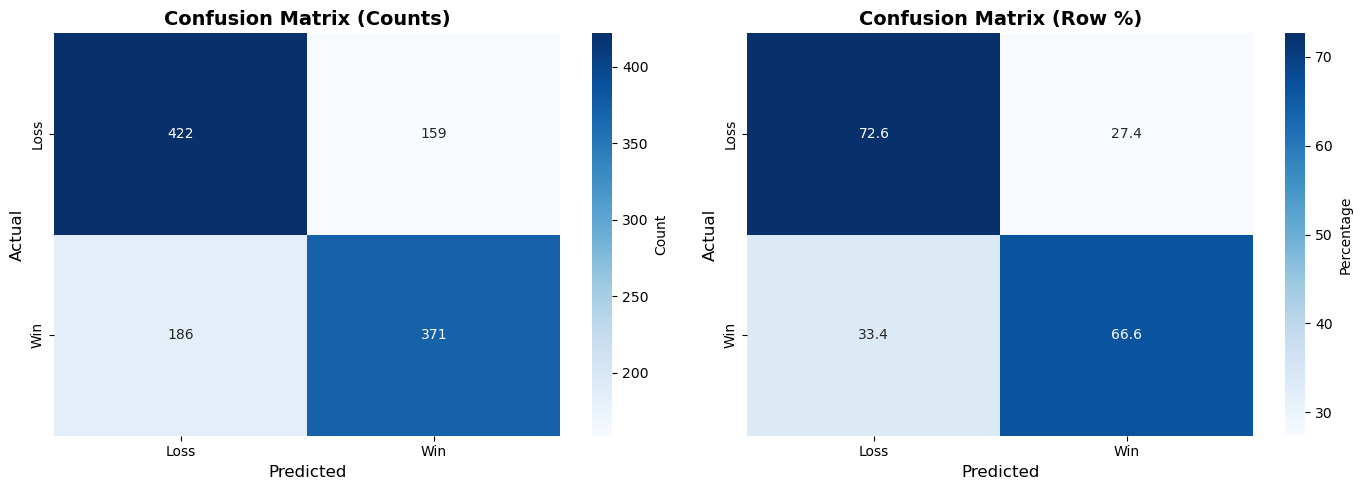

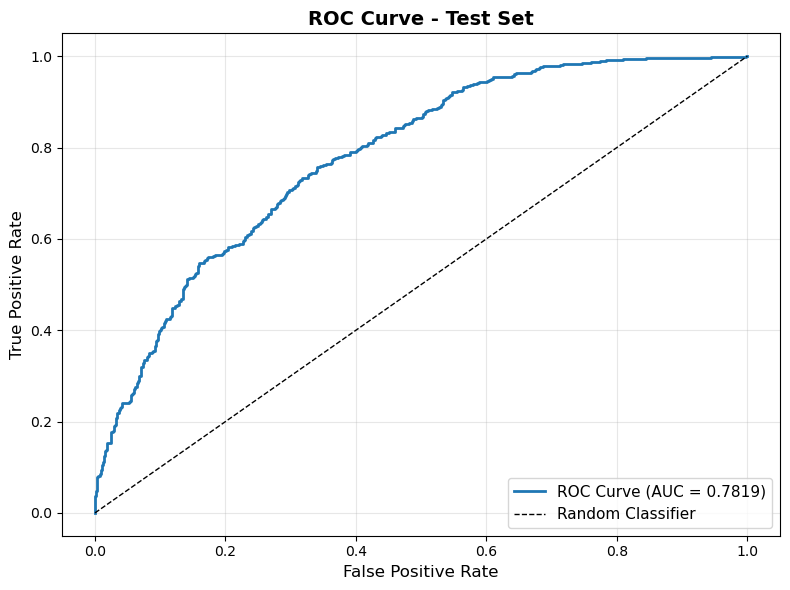

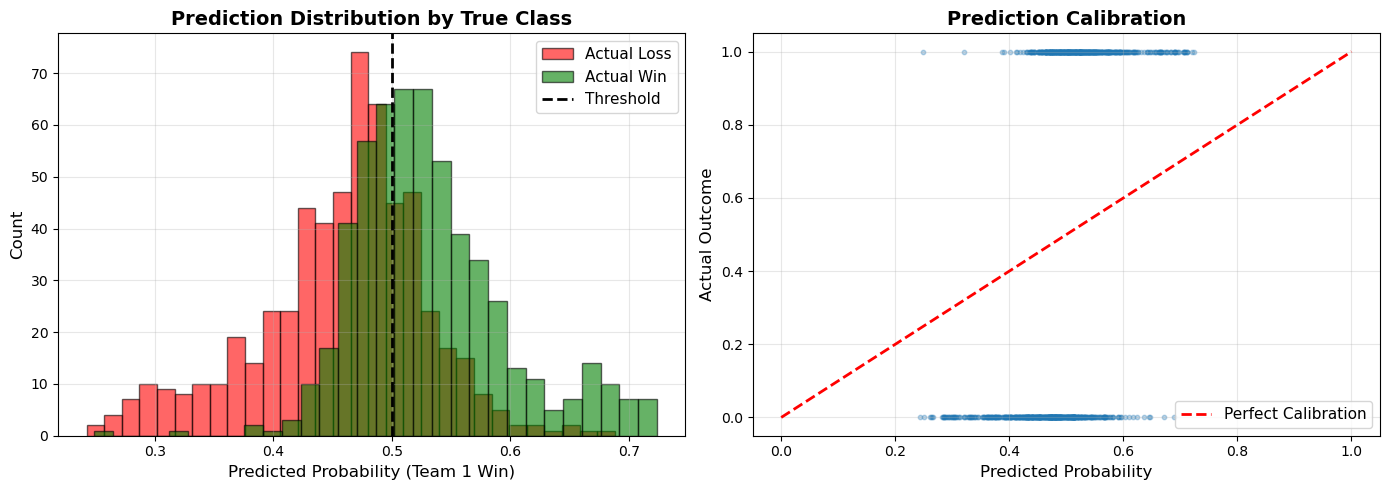

✓ Evaluation complete!


In [24]:
# Comprehensive Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Convert probabilities to binary predictions (threshold = 0.5)
all_preds = (all_probs > 0.5).astype(int)

# Compute metrics
accuracy = accuracy_score(all_targets, all_preds)
auc = roc_auc_score(all_targets, all_probs)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"AUC Score:       {auc:.4f}")
print(f"Accuracy:        {accuracy:.4f}")
print(f"Total Samples:   {len(all_targets)}")
print()

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
print("Confusion Matrix:")
print("                 Predicted")
print("                 Loss  |  Win")
print(f"Actual  Loss    {cm[0,0]:4d}  | {cm[0,1]:4d}")
print(f"        Win     {cm[1,0]:4d}  | {cm[1,1]:4d}")
print()

# Confusion matrix percentages
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix (Percentages):")
print(f"True Negatives:   {tn} ({100*tn/len(all_targets):.1f}%)")
print(f"False Positives:  {fp} ({100*fp/len(all_targets):.1f}%)")
print(f"False Negatives:  {fn} ({100*fn/len(all_targets):.1f}%)")
print(f"True Positives:   {tp} ({100*tp/len(all_targets):.1f}%)")
print()

# Classification report
print("Classification Report:")
print(classification_report(all_targets, all_preds, 
                          target_names=['Loss (0)', 'Win (1)'],
                          digits=4))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap with counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Loss', 'Win'],
            yticklabels=['Loss', 'Win'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Heatmap with percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Loss', 'Win'],
            yticklabels=['Loss', 'Win'],
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Row %)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by true class
axes[0].hist(all_probs[all_targets.flatten() == 0], bins=30, alpha=0.6, 
             label='Actual Loss', color='red', edgecolor='black')
axes[0].hist(all_probs[all_targets.flatten() == 1], bins=30, alpha=0.6,
             label='Actual Win', color='green', edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Predicted Probability (Team 1 Win)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Prediction Distribution by True Class', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Calibration scatter
axes[1].scatter(all_probs, all_targets, alpha=0.3, s=10)
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Calibration')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Actual Outcome', fontsize=12)
axes[1].set_title('Prediction Calibration', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Evaluation complete!")


## Grid Search on Validation Set for Hyperparameter Tuning

Last 80 regular season games as validation

In [ ]:


import itertools
import json
from datetime import datetime

# Define grid search space
PARAM_GRID = {
    'latent_dim': [32, 64],
    'hidden_dim': [64, 128],
    'num_layers': [3, 5],
    'dropout': [0.3, 0.5],
    'batch_size': [32, 64],
    'learning_rate': [1e-3],
    'max_prev_games': [5, 15, -1],
}

# Generate all combinations
param_combinations = list(itertools.product(*PARAM_GRID.values()))
param_names = list(PARAM_GRID.keys())

print(f"GRID SEARCH: {len(param_combinations)} configurations")


regular_season_indices = df[df['is_tournament_game'] == False].index.tolist()
test_indices = df[df['is_tournament_game'] == True].index.tolist()

val_size = 80
train_indices_gs = regular_season_indices[:-val_size]
val_indices_gs = regular_season_indices[-val_size:]


def train_and_evaluate_config(params_dict, train_idx, val_idx, df_data, n_epochs=7, patience=3):
    """Train model with given hyperparameters and return validation metrics."""
    
    # Custom dataset with max_prev_games
    class CustomDataset(GameSequenceDataset):
        def __init__(self, df, use_indices, max_games):
            super().__init__(df, use_indices)
            self.max_games = max_games
            
        def _get_team_sequence(self, team_id, current_game_idx, max_prev_games=None):
            if max_prev_games is None:
                max_prev_games = self.max_games
            return super()._get_team_sequence(team_id, current_game_idx, max_prev_games)
    
    train_ds = CustomDataset(df_data, train_idx, params_dict['max_prev_games'])
    val_ds = CustomDataset(df_data, val_idx, params_dict['max_prev_games'])
    
    train_loader = DataLoader(train_ds, params_dict['batch_size'], shuffle=True, collate_fn=collate_variable_length)
    val_loader = DataLoader(val_ds, params_dict['batch_size'], shuffle=False, collate_fn=collate_variable_length)
    
    model = RecurrentGamePredictor(
        input_size=len(train_ds.stat_cols),
        hidden_dim=params_dict['hidden_dim'],
        num_layers=params_dict['num_layers'],
        latent_dim=params_dict['latent_dim'],
        dropout=params_dict['dropout'],
        max_prev_games=params_dict['max_prev_games']
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=params_dict['learning_rate'], weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    best_val_auc = 0
    patience_counter = 0
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        for team_a_seq, len_a, team_b_seq, len_b, targets in train_loader:
            team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
            team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
            targets = targets.to(device).view(-1, 1).float()
            
            optimizer.zero_grad()
            logits, _, _ = model(team_a_seq, len_a, team_b_seq, len_b)
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Validate
        model.eval()
        val_probs, val_targets = [], []
        with torch.no_grad():
            for team_a_seq, len_a, team_b_seq, len_b, targets in val_loader:
                team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
                team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
                targets = targets.to(device).view(-1, 1).float()
                
                logits, _, _ = model(team_a_seq, len_a, team_b_seq, len_b)
                probs = torch.sigmoid(logits)
                val_probs.append(probs.cpu().numpy())
                val_targets.append(targets.cpu().numpy())
        
        val_probs = np.concatenate(val_probs)
        val_targets = np.concatenate(val_targets)
        val_auc = roc_auc_score(val_targets, val_probs)
        val_acc = accuracy_score(val_targets, (val_probs > 0.5).astype(int))
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    return {'val_auc': best_val_auc, 'val_acc': best_val_acc}

# %%
# Execute grid search
results = []
best_auc = 0
best_params = None

for i, param_values in enumerate(tqdm(param_combinations, desc="Grid Search")):
    params = dict(zip(param_names, param_values))
    
    try:
        metrics = train_and_evaluate_config(params, train_indices_gs, val_indices_gs, df, n_epochs=3, patience=3)
        result = {'params': params, **metrics}
        results.append(result)
        
        if metrics['val_auc'] > best_auc:
            best_auc = metrics['val_auc']
            best_params = params
    
    except Exception as e:
        results.append({'params': params, 'val_auc': 0, 'val_acc': 0, 'error': str(e)})






GRID SEARCH: 96 configurations


Grid Search:   0%|          | 0/96 [00:00<?, ?it/s]

Grid Search:  46%|████▌     | 44/96 [35:49<42:21, 48.87s/it]  

In [ ]:
# Sort results
results_sorted = sorted(results, key=lambda x: x['val_auc'], reverse=True)

print(f"\n{'='*100}")
print("TOP 10 CONFIGURATIONS:")
print(f"{'='*100}")
print(f"{'Rank':<5} {'Val AUC':<10} {'Val Acc':<10} {'Parameters'}")
print(f"{'-'*100}")

for rank, result in enumerate(results_sorted[:10], 1):
    params_str = ", ".join([f"{k}={v}" for k, v in result['params'].items()])
    print(f"{rank:<5} {result['val_auc']:<10.4f} {result['val_acc']:<10.4f} {params_str}")

print(f"\nBEST: AUC={results_sorted[0]['val_auc']:.4f}, Params: {results_sorted[0]['params']}")

# Save results
with open('grid_search_results.json', 'w') as f:
    json.dump({'best_params': results_sorted[0]['params'], 'best_val_auc': results_sorted[0]['val_auc'], 
               'top_10': results_sorted[:10]}, f, indent=2)

print(f"✓ Results saved to grid_search_results.json")


## Bracket Prediction (legacy)

In [ ]:
def predict_bracket(model, dataset, team_matchups):
    """
    Predict tournament bracket given first round matchups.
    
    Args:
        model: Trained RecurrentGamePredictor model
        dataset: GameSequenceDataset instance with full historical data
        team_matchups: List of tuples (team1_name, team2_name) for first round
                      Should be 32 teams = 16 matchups
                      Order matters: Lower seed should be team1 (underdog)
    Returns:
        dict: Complete bracket with probabilities
    """
    model.eval()
    device = next(model.parameters()).device
    name_to_id = dataset.team_encoder

    # Use all history up to "now"
    current_game_idx = len(dataset.df)

    # Round name resolver from number of initial matchups
    round_order = ["Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Championship"]
    start_from_map = {32:0, 16:1, 8:2, 4:3, 2:4, 1:5}
    if len(team_matchups) not in start_from_map:
        raise ValueError("team_matchups length must be one of {32,16,8,4,2,1}.")
    start_idx = start_from_map[len(team_matchups)]

    # Prepare bracket container
    bracket = {rn: [] for rn in round_order[start_idx:]}
    bracket["Champion"] = None

    # Helpers
    def _team_seq(team_name):
        tid = name_to_id[team_name]
        seq = dataset._get_team_sequence(tid, current_game_idx)  # (L,F) possibly L=0
        if seq.shape[0] == 0:
            n_feat = dataset.n_features()
            seq = np.zeros((1, n_feat), dtype=np.float32)
            L = 1
        else:
            L = seq.shape[0]
        x = torch.tensor(seq, dtype=torch.float32, device=device).unsqueeze(0)   # (1,L,F)
        l = torch.tensor([L], dtype=torch.long, device=device)
        return x, l
    
    def _get_static(team_name):
        tid = name_to_id[team_name]
        row = dataset.df[dataset.df['Team 1'] == tid]
        if row.empty:
            row = dataset.df[dataset.df['Team 2'] == tid]
        elo = row.iloc[-1]['Elo1'] if row.iloc[-1]['Team 1'] == tid else row.iloc[-1]['Elo2']
        static_feat = torch.tensor([[elo]], dtype=torch.float32, device=device)
        return static_feat

    def _predict(a, b):
        with torch.no_grad():
            xa, la = _team_seq(a)
            xb, lb = _team_seq(b)
            sa = _get_static(a)
            sb = _get_static(b)
            logits = model(xa, la, xb, lb, sa, sb)
            p_a = torch.sigmoid(logits).item()  # prob team A wins
        winner = a if p_a >= 0.5 else b
        conf = p_a if winner == a else 1.0 - p_a
        return p_a, winner, conf

    # Main single-loop over rounds
    pairs = team_matchups[:]  # list of (A,B)


    for round_name in round_order[start_idx:]:
        winners = []
        for (a, b) in pairs:
            p_a, winner, conf = _predict(a, b)
            bracket[round_name].append({
                "team1": a,
                "team2": b,
                "prob_team1": p_a,   # probability that the first team in the pair wins
                "winner": winner,
                "confidence": conf    # probability of the winner
            })
            winners.append(winner)
            print(f"{round_name}: {a} vs {b} => Winner: {winner} (P={p_a:.3f})")

        if len(winners) == 1:
            bracket["Champion"] = winners[0]
            break

        # Pair adjacent winners for the next round
        pairs = [(winners[i], winners[i+1]) for i in range(0, len(winners), 2)]

    return bracket

# Example bracket prediction (uncomment and modify team names) (legacy)

In [ ]:
def extract_first_round_matchups(df):
    required = {"Team 1", "Team 2", "is_tournament_game"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    tourney_games = df[df["is_tournament_game"] == True].copy()
    first_round = tourney_games.head(32)

    # Build list of (Team 1, Team 2) tuples
    matchups = list(zip(first_round["Team 1"], first_round["Team 2"]))

    return matchups

In [ ]:
team_matchups = extract_first_round_matchups(df)
len(team_matchups)

32

In [ ]:
all_dataset = GameSequenceDataset(df)
bracket_prediction = predict_bracket(model, all_dataset, team_matchups)

Round of 64: Pacific vs Pittsburgh => Winner: Pittsburgh (P=0.351)
Round of 64: Cincinnati vs Iowa => Winner: Cincinnati (P=0.528)
Round of 64: Alabama vs Milwaukee => Winner: Alabama (P=0.721)
Round of 64: Gonzaga vs Winthrop => Winner: Gonzaga (P=0.754)
Round of 64: Louisiana State vs UAB => Winner: UAB (P=0.295)
Round of 64: UTEP vs Utah => Winner: Utah (P=0.365)
Round of 64: Creighton vs West Virginia => Winner: Creighton (P=0.574)
Round of 64: FDU vs Illinois => Winner: Illinois (P=0.272)
Round of 64: Eastern Kentucky vs Kentucky => Winner: Kentucky (P=0.340)
Round of 64: Niagara vs Oklahoma => Winner: Oklahoma (P=0.415)
Round of 64: Montana vs Washington => Winner: Washington (P=0.461)
Round of 64: Texas Tech vs UCLA => Winner: UCLA (P=0.393)
Round of 64: Chattanooga vs Wake Forest => Winner: Wake Forest (P=0.442)
Round of 64: Nevada vs Texas => Winner: Texas (P=0.391)
Round of 64: Arizona vs Utah State => Winner: Arizona (P=0.595)
Round of 64: Boston College vs Pennsylvania => W

# For Anthony

In [ ]:
def predict_upset(model, dataset, favorite, underdog):
    """
    Predicts if the underdog will win against the favorite.
    
    Args:
        model: Trained RecurrentGamePredictor model
        dataset: GameSequenceDataset instance
        favorite: Name of the favorite team
        underdog: Name of the underdog team
        
    Returns:
        bool: True if the model predicts the underdog wins (upset), False otherwise.
    """
    model.eval()
    device = next(model.parameters()).device
    name_to_id = dataset.team_encoder
    current_game_idx = len(dataset.df)

    # Helper to get sequence
    def _team_seq(team_name):
        if team_name not in name_to_id:
            raise ValueError(f"Team '{team_name}' not found in dataset.")
        tid = name_to_id[team_name]
        seq = dataset._get_team_sequence(tid, current_game_idx)
        if seq.shape[0] == 0:
            n_feat = dataset.n_features()
            seq = np.zeros((1, n_feat), dtype=np.float32)
            L = 1
        else:
            L = seq.shape[0]
        x = torch.tensor(seq, dtype=torch.float32, device=device).unsqueeze(0)
        l = torch.tensor([L], dtype=torch.long, device=device)
        return x, l

    # Helper to get static features (Elo)
    def _get_static(team_name):
        tid = name_to_id[team_name]
        # Find last game for Elo
        row = dataset.df[dataset.df['Team 1'] == tid]
        if row.empty:
            row = dataset.df[dataset.df['Team 2'] == tid]
        
        if row.empty:
             elo = 1000.0 
        else:
            elo = row.iloc[-1]['Elo1'] if row.iloc[-1]['Team 1'] == tid else row.iloc[-1]['Elo2']
            
        static_feat = torch.tensor([[elo]], dtype=torch.float32, device=device)
        return static_feat

    with torch.no_grad():
        # Prepare inputs
        xa, la = _team_seq(favorite)
        xb, lb = _team_seq(underdog)
        sa = _get_static(favorite)
        sb = _get_static(underdog)
        
        # Model output is logit for Team A (favorite) winning
        logits = model(xa, la, xb, lb, sa, sb)
        prob_favorite_wins = torch.sigmoid(logits).item()
        
    # If prob_favorite_wins < 0.5, then underdog is predicted to win
    is_upset = prob_favorite_wins < 0.5
    
    print(f"Matchup: {favorite} (Fav) vs {underdog} (Und)")
    print(f"Win Prob for {favorite}: {prob_favorite_wins:.2%}")
    print(f"Predicted Winner: {underdog if is_upset else favorite}")
    
    return is_upset

In [ ]:
# ex. use: (execute the previous cells first to define model and dataset, don't have to run train or validation)

config = torch.load('checkpoints/checkpoint_latest.pth')['metadata']['config']
model = RecurrentGamePredictor(
    input_size=len(train_dataset.stat_cols),
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    latent_dim=config['latent_dim'],
    dropout=config['dropout'],
    max_prev_games=config['max_prev_games']
).to(device)

model.load_state_dict(torch.load('checkpoints/checkpoint_latest.pth')['model_state_dict'])

df = pd.read_csv("./InputData2023.csv")     # suppose using 2023 as test data
df = df.sort_values(by='Date').reset_index(drop=True)

dataset = GameSequenceDataset(df)

predict_upset(model, dataset, favorite="Duke", underdog="Oral Roberts")

Matchup: Duke (Fav) vs Oral Roberts (Und)
Win Prob for Duke: 53.27%
Predicted Winner: Duke


False